In [ ]:
!pip install kagglehub

# Clusterização de Grupos Alimentares e Contaminação por Microplásticos
Este projeto busca identificar padrões de consumo alimentar e sua associação com contaminação por microplásticos ao longo dos anos, com base no dataset disponível no Kaggle.

## Imports

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


## Carregamento dos Dados

In [ ]:
dataset_path = kagglehub.dataset_download('jayeshrmohanani/dataset-for-microplastic-consumption-in-food-items')

import os
print("Arquivos disponíveis:")
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

Arquivos disponíveis:
/kaggle/input/dataset-for-microplastic-consumption-in-food-items/processed_microplastics.csv
/kaggle/input/dataset-for-microplastic-consumption-in-food-items/train.csv


In [ ]:
path_processed = '/kaggle/input/dataset-for-microplastic-consumption-in-food-items/processed_microplastics.csv'
df = pd.read_csv(path_processed)
print(df.shape)
df.head()


(723, 21)


,year,country,cheese,yoghurt,total_milk,fruits,refined_grains,whole_grains,nuts_and_seeds,total_processed_meats,...,fish,shellfish,eggs,total_salt,added_sugars,non-starchy_vegetables,potatoes,other_starchy_vegetables,beans_and_legumes,total_ug_per_kg
0,1990,Angola,0.191781,54.899739,96.602740,76.520548,481.297149,44.309838,2.849315,22.770109,...,53.013699,0.164384,1.041096,8.005259,32.547945,80.164384,8.109589,39.342466,19.835616,1043.279108
1,1990,Benin,0.054795,9.365946,18.410959,90.876712,534.256965,48.836323,19.561644,17.018264,...,18.794521,3.972603,2.849315,5.854497,8.246575,122.986301,0.000000,304.904110,21.178082,1241.656197
2,1990,Burkina Faso,0.273973,35.390618,56.027397,19.178082,213.170183,129.416119,28.465753,9.541329,...,4.684932,0.000000,6.767123,6.928378,9.534247,64.767123,2.219178,13.780822,32.520548,666.603927
3,1990,Central African Republic,0.000000,19.206478,48.000000,113.397260,285.035375,302.567776,23.506849,26.412094,...,13.917808,0.000000,1.123288,6.585071,19.698630,101.753425,0.575342,209.452055,12.821918,1237.339905
4,1990,Cote D'Ivoire,0.301370,2.220447,38.109589,37.013699,436.907598,25.220347,16.904110,2.459103,...,51.424658,0.493151,2.438356,9.660915,28.438356,151.150685,1.945205,676.575343,2.356164,1540.502458


## Visão Geral dos Dados

In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 723 entries, 0 to 722
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      723 non-null    int64  
 1   country                   723 non-null    object 
 2   cheese                    723 non-null    float64
 3   yoghurt                   723 non-null    float64
 4   total_milk                723 non-null    float64
 5   fruits                    723 non-null    float64
 6   refined_grains            723 non-null    float64
 7   whole_grains              723 non-null    float64
 8   nuts_and_seeds            723 non-null    float64
 9   total_processed_meats     723 non-null    float64
 10  unprocessed_red_meats     723 non-null    float64
 11  fish                      723 non-null    float64
 12  shellfish                 723 non-null    float64
 13  eggs                      723 non-null    float64
 14  total_salt

,year,cheese,yoghurt,total_milk,fruits,refined_grains,whole_grains,nuts_and_seeds,total_processed_meats,unprocessed_red_meats,fish,shellfish,eggs,total_salt,added_sugars,non-starchy_vegetables,potatoes,other_starchy_vegetables,beans_and_legumes,total_ug_per_kg
count,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000,723.000000
mean,2005.113416,6.135622,54.175691,250.655223,198.891339,310.733750,76.090720,12.716421,43.242799,90.326727,40.367154,7.415298,17.184714,6.844069,87.980939,232.405995,81.885598,64.300877,19.261638,1600.614574
std,9.610611,10.437505,77.868834,243.250670,150.271271,138.658231,81.578881,10.827892,39.223624,67.646655,34.835918,13.695479,14.584195,1.806978,60.331304,164.633624,83.109875,135.136514,16.758578,567.115360
min,1990.000000,0.000000,0.748435,1.808219,8.958904,72.797775,0.158798,0.000000,0.396227,6.583087,0.054795,0.000000,0.027397,2.278036,3.972603,16.931507,0.000000,0.000000,0.438356,440.261767
25%,1995.000000,0.273973,12.048883,50.342466,89.808219,216.258939,16.965904,4.561644,11.560798,33.837311,15.726027,0.191781,3.876712,5.845209,38.753425,118.287671,12.205479,0.493151,7.821918,1176.251294
50%,2005.000000,1.424658,35.390618,153.506849,179.945205,288.254183,47.164800,9.589041,29.473811,71.678223,31.232877,1.589041,13.780822,6.660399,83.698630,185.945205,49.561644,8.547945,14.794521,1550.939573
75%,2015.000000,6.082192,73.449547,400.890411,266.863014,383.983087,101.764947,18.410959,66.736055,134.673403,54.506849,8.630137,27.657534,7.659304,117.616438,292.479452,135.876712,59.123288,25.561644,2061.390253
max,2018.000000,65.643836,679.834239,1040.931507,1078.931507,890.394188,434.121124,73.068493,198.333731,477.301388,207.315068,151.863014,61.698630,12.430686,453.780822,1055.342466,362.712329,833.945206,124.575343,3613.131482


## Pré-processamento

In [ ]:
# Remover colunas irrelevantes
df = df.drop(columns=["country"])  # manter 'year' para análise temporal

# Tratar valores nulos
imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Normalização
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df.columns)


## Evolução Temporal do Consumo de Microplástico

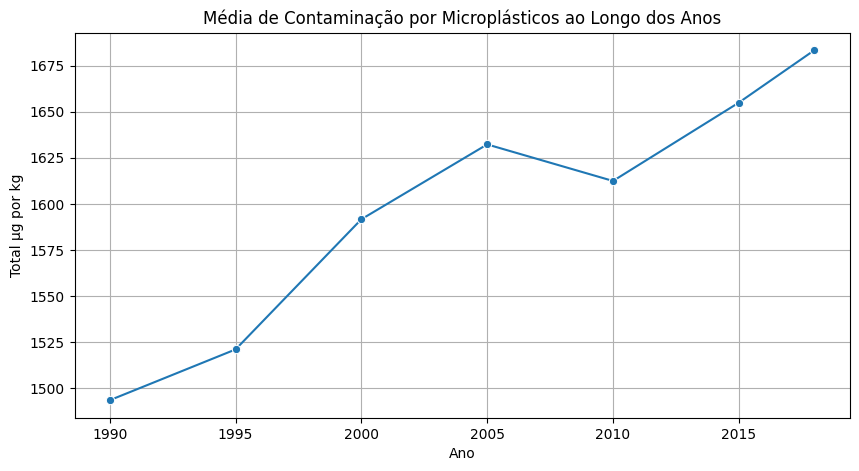

In [ ]:
yearly_trend = df.groupby("year")["total_ug_per_kg"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_trend, x="year", y="total_ug_per_kg", marker="o")
plt.title("Média de Contaminação por Microplásticos ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Total µg por kg")
plt.grid(True)
plt.show()


## Clusterização com K-Means

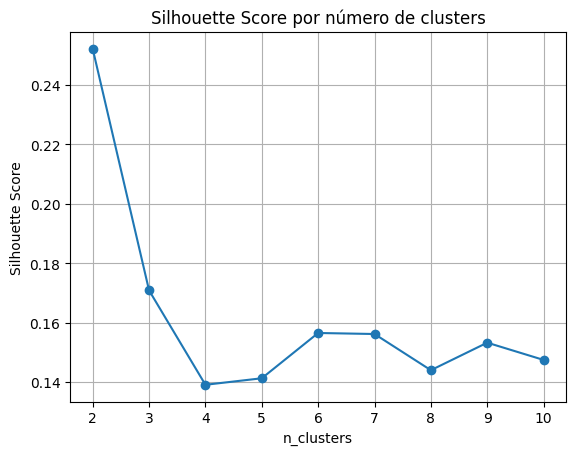

In [ ]:
# Remover 'year' para clusterização
features = df_scaled.drop(columns=["year"])

# Otimização do número de clusters
scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    scores.append(silhouette_score(features, kmeans.labels_))

plt.plot(K_range, scores, marker="o")
plt.title("Silhouette Score por número de clusters")
plt.xlabel("n_clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# K-Means final
kmeans = KMeans(n_clusters=6, random_state=42)
df["Cluster"] = kmeans.fit_predict(features)


## Visualização dos Clusters com PCA

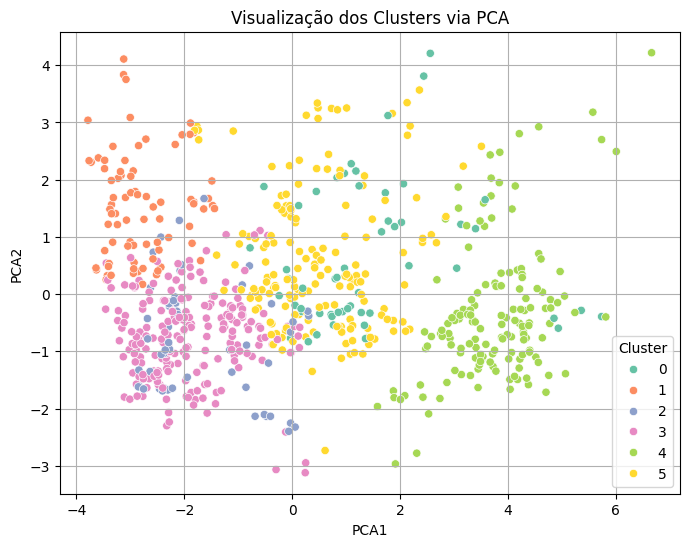

In [ ]:
pca = PCA(n_components=2)
components = pca.fit_transform(features)
df["PCA1"] = components[:, 0]
df["PCA2"] = components[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette="Set2")
plt.title("Visualização dos Clusters via PCA")
plt.grid(True)
plt.show()


## Análise dos Clusters

In [ ]:
cluster_summary = df.groupby("Cluster")[["total_ug_per_kg", "year", ]].mean()
cluster_summary


,total_ug_per_kg,year
Cluster,,
0,1588.657265,2007.547170
1,1464.702662,2006.481013
2,1312.881754,2003.641509
3,1021.089780,2003.118721
4,2277.445175,2005.715232
5,1906.180808,2006.226190


## Evolução Temporal por Cluster

/tmp/ipython-input-12-583483840.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="year", y="total_ug_per_kg", hue="Cluster", ci=None)


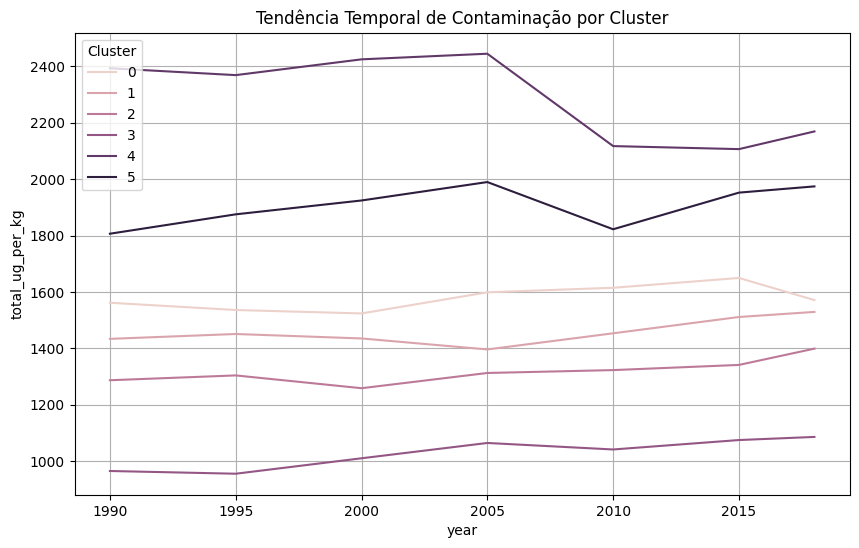

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="year", y="total_ug_per_kg", hue="Cluster", ci=None)
plt.title("Tendência Temporal de Contaminação por Cluster")
plt.grid(True)
plt.show()
